# Bicapa estratificada con $\mu_s$ igualado — análisis final curado

Este notebook contiene únicamente el flujo necesario para las figuras que pueden sostener
la sección final de resultados. Reemplaza la organización exploratoria `MM0`--`MM7`.

## Pregunta

¿Qué cambia en el cono CBS cuando dos especies con la misma frecuencia de colisión dejan de
estar mezcladas y se segregan en profundidad?

La construcción fija

$$
\mu_s^{\rm S}=\mu_s^{\rm L},\qquad
\ell_s^{\rm S}=\ell_s^{\rm L}\equiv\ell_s,
$$

pero conserva funciones de fase diferentes:

$$
g_{\rm S}\simeq0.053,\qquad g_{\rm L}\simeq0.484,\qquad
\frac{\ell_{\rm L}^*}{\ell_{\rm S}^*}\simeq1.82.
$$

Por tanto se elimina el contraste en el número medio de colisiones por unidad de longitud.
El contraste restante está en la redistribución angular por evento; $\ell^*$ resume su primer
momento, pero no reemplaza la función de fase completa.

## Figuras retenidas

1. Perfiles estacionarios en el canal lineal.
2. Fallo de una forma homogénea común en el canal lineal.
3. Excursión del ápice fuera del intervalo de los controles homogéneos.
4. Diagnóstico temporal de bicapas delgadas, condicionado a que la meseta sea estable.

Las pruebas de regla $\ell_s$ frente a $\ell^*$, la ley browniana de $w(d)$, la inversión
general del espesor y el ajuste de $t^*\propto d^2$ no forman parte de las figuras finales.


## 1. Entorno y convenciones

Las figuras se guardan en `figs_tesis_bicapa_mus_final/`. Las cuatro campañas se cargan
desde sus snapshots archivados. Como sus grillas difieren ligeramente, toda comparación
entre campañas interpola explícitamente sobre una grilla de referencia.


In [2]:
# ===========================================================================
# 0 -- entorno
# ===========================================================================
import sys, os, re, pathlib, warnings
import matplotlib

sys.path.append(os.path.abspath("../../"))

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, field
from scipy import stats
from scipy.optimize import curve_fit

from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE, COL
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

FIGDIR = pathlib.Path("figs_tesis_bicapa_mus_final")
FIGDIR.mkdir(exist_ok=True)

# --- ubicacion de las cuatro campanias -------------------------------------
BASE_PATH = "/Users/niaggar/Results"
FOLDERS = {
    ("normal",  "circular"): "study_two_layers_MUS__NORMAL__PCIR__beam2500",
    ("normal",  "linear")  : "study_two_layers_MUS__NORMAL__PLIN__beam2500",
    ("inverse", "circular"): "study_two_layers_MUS__INVERSE__PCIR__beam2500",
    ("inverse", "linear")  : "study_two_layers_MUS__INVERSE__PLIN__beam2500",
}

N_MEDIUM, WAVELENGTH = 1.33, 0.514
k     = 2 * np.pi * N_MEDIUM / WAVELENGTH        # um^-1
C0    = 0.299792458                              # um/fs
V_MED = C0 / N_MEDIUM                            # um/fs en el medio
eps   = 1e-30

CONV = dict(
    phi_main        = 0,        # corte azimutal (obligatorio en lineal)
    n_apex          = 5,        # bins usados para extrapolar el apice
    apex_mode       = "cusp",   # 'cusp' (recomendado) | 'median'
    q_min_baseline  = 25.0,     # cola para la linea base, en q comun
    x_lo            = 0.25,     # niveles del invariante de forma
    x_hi            = 0.75,
    q_view          = 6.0,      # ventana de las figuras, en q
    q_view_apex     = 1.2,      # zoom del apice
    q_fit           = 5.0,      # ventana de ajuste de MM4
    conf            = 0.975,
    snr_min_time    = 5.0,      # compuerta de calidad por bin temporal
    monotone_levels = True,     # envolvente monotona antes de invertir niveles
)

def t_ci(n, conf=CONV["conf"]):
    """Factor t de Student de dos colas."""
    return float(stats.t.ppf(conf, n - 1))

# --- constantes teoricas (cero parametros libres) --------------------------
B_MILNE   = 0.7104              # z0/l*, condicion de Milne
ZETA_TEO  = 1.0 + B_MILNE       # profundidad caracteristica de w(m)
ALPHA_TEO = 1.5                 # t* = alpha m^2 tau*_ent

STYLE = {
    "normal":  dict(color=COL[0], marker="o", ls="-",  label="normal"),
    "inverse": dict(color=COL[1], marker="s", ls="--", label="inverse"),
}
POLSTYLE = {"circular": dict(ls="-"), "linear": dict(ls="--")}

print(f"k = {k:.4f} um^-1     t(0.975,4) = {t_ci(5):.3f}")


k = 16.2580 um^-1     t(0.975,4) = 2.776


## 2. Funciones de reducción

El valor central de un perfil es el cociente de intensidades sumadas sobre réplicas.
Los escalares y sus intervalos se calculan por réplica. El ápice se obtiene extrapolando
la cúspide lineal hacia \(q=0\).


In [3]:
# ===========================================================================
# 1a -- resolucion de canales, stitching, linea base
# ===========================================================================
CHANNEL_OVERRIDE = {}      # p.ej. {"circular": "same", "linear": "co"} para forzar


def _basis_for(pol):
    return circular if pol == "circular" else linear


def _chan_names(prof):
    c = prof.coherent
    try:
        return list(c.keys())
    except AttributeError:
        return [a for a in dir(c) if not a.startswith("_")]


def _chan_get(prof, name, which="coherent"):
    obj = getattr(prof, which)
    try:
        return np.asarray(obj[name], float)
    except (TypeError, KeyError):
        return np.asarray(getattr(obj, name), float)


def raw_profiles(sweep, key, pol, channel, time_index=0):
    """(p1, p2) crudos de las dos ventanas angulares, un solo corte azimutal."""
    sw = sweep[key]
    b = _basis_for(pol)
    p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=b,
                      time_index=time_index, reduce=phi_cut(CONV["phi_main"]))
    p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=b,
                      time_index=time_index, reduce=phi_cut(CONV["phi_main"]))
    return p1, p2


def stitch(th1, y1, th2, y2, key="", warn=0.05):
    """Une ventana fina y cola; avisa si el solape no concuerda."""
    th_1 = th1[-1]
    ov = (th2 >= 0.9 * th_1) & (th2 <= th_1)
    if ov.any():
        resid = np.abs(y2[ov] - np.interp(th2[ov], th1, y1))
        if np.max(resid) > warn:
            print(f"[stitch WARN] {key}: max desacuerdo en solape = {np.max(resid):.3f}")
    keep2 = th2 > th_1
    return (np.concatenate([th1, th2[keep2]]),
            np.concatenate([y1, y2[keep2]]))


def tail_baseline(q, y, q_min=CONV["q_min_baseline"], n_min=5, frac=0.85):
    """Mediana de la cola en q comun. Si la ventana no alcanza, usa el 15 % final."""
    q, y = np.asarray(q, float), np.asarray(y, float)
    m = q > q_min
    if np.count_nonzero(m) >= n_min:
        return float(np.median(y[m]))
    m = q >= frac * np.nanmax(q)
    if np.count_nonzero(m) < n_min:
        return float(np.median(y[np.argsort(q)[-n_min:]]))
    return float(np.median(y[m]))


In [4]:
# ===========================================================================
# 1b -- perfiles: una replica y sumado sobre replicas
# ===========================================================================
def profile_one(sweep, key, pol, channel, l_anchor, time_index=0):
    """(q, eta) de UNA replica; linea base llevada a 1.
    Se usa SOLO para barras de error de escalares (la unidad estadistica
    independiente es la replica, no el bin)."""
    p1, p2 = raw_profiles(sweep, key, pol, channel, time_index)
    E1 = (_chan_get(p1, channel, "coherent") + eps) / (_chan_get(p1, channel, "incoherent") + eps)
    E2 = (_chan_get(p2, channel, "coherent") + eps) / (_chan_get(p2, channel, "incoherent") + eps)
    th, E = stitch(np.asarray(p1.theta), E1, np.asarray(p2.theta), E2, key)
    q = k * l_anchor * th
    return q, E - tail_baseline(q, E) + 1.0


def profile_sum(sweep, keys, pol, channel, l_anchor, time_index=0):
    """(q, eta) por cociente de intensidades SUMADAS sobre replicas.
    Estimador correcto del valor central: sum(C)/sum(I), no el promedio de
    cocientes por replica (sesgo de estimador de razon, ec. 17-18)."""
    Ic = Ii = th1 = th2 = None
    for key in keys:
        p1, p2 = raw_profiles(sweep, key, pol, channel, time_index)
        c1, c2 = _chan_get(p1, channel), _chan_get(p2, channel)
        b1, b2 = _chan_get(p1, channel, "incoherent"), _chan_get(p2, channel, "incoherent")
        if Ic is None:
            Ic = [np.zeros_like(c1), np.zeros_like(c2)]
            Ii = [np.zeros_like(b1), np.zeros_like(b2)]
            th1, th2 = np.asarray(p1.theta), np.asarray(p2.theta)
        Ic[0] += c1; Ic[1] += c2; Ii[0] += b1; Ii[1] += b2
    keep2 = th2 > th1[-1]
    th = np.concatenate([th1, th2[keep2]])
    Ct = np.concatenate([Ic[0], Ic[1][keep2]])
    It = np.concatenate([Ii[0], Ii[1][keep2]])
    E = (Ct + eps) / (It + eps)
    q = k * l_anchor * th
    return q, E - tail_baseline(q, E) + 1.0


In [5]:
# ===========================================================================
# 1c -- escalares robustos a un perfil de dos escalas
# ===========================================================================
def apex_value(q, E, n=None, mode=None):
    """Valor del apice eta(0).

    El pico CBS es NO analitico en theta=0: eta ~ eta(0) - beta*q + O(q^2)
    (cuspide triangular, ec. 12). Promediar los primeros bins subestima el
    apice, y lo subestima MAS para conos estrechos -> mete una dependencia
    espuria con l* en toda cantidad normalizada por eta(0). Extrapolar la recta
    de la cuspide a q=0 elimina ese sesgo a primer orden para CUALQUIER forma
    de linea, y promedia ruido sobre n bins. La celda de calibracion de abajo
    fija n comparando sesgo (piso sintetico) contra ruido (dispersion entre
    replicas)."""
    n = CONV["n_apex"] if n is None else n
    mode = CONV["apex_mode"] if mode is None else mode
    E = np.asarray(E, float)
    if mode == "median":
        return float(np.median(E[:n]))
    p = np.polyfit(np.asarray(q, float)[:n], E[:n], 1)
    return float(p[1])


def excess_norm(q, E, monotone=None):
    """(eta-1)/(eta(0)-1), con envolvente monotona decreciente opcional.
    Un cono es monotonamente decreciente; imponerlo elimina cruces espurios por
    ruido sin tocar la senal, y se aplica igual a datos, controles y familia
    sintetica, asi que cualquier sesgo residual se cancela en razones."""
    monotone = CONV["monotone_levels"] if monotone is None else monotone
    E0 = apex_value(q, E)
    if not np.isfinite(E0) or E0 <= 1.0:
        return None
    y = (np.asarray(E, float) - 1.0) / (E0 - 1.0)
    return np.minimum.accumulate(y) if monotone else y


def level_q(q, E, x):
    """q donde el exceso normalizado cae a la fraccion x del apice."""
    y = excess_norm(q, E)
    if y is None:
        return np.nan
    b = np.where(y < x)[0]
    b = b[b > 0]
    if len(b) == 0:
        return np.nan
    i = int(b[0])
    if y[i] == y[i - 1]:
        return np.nan
    return float(q[i - 1] + (x - y[i - 1]) * (q[i] - q[i - 1]) / (y[i] - y[i - 1]))


def shape_invariant(q, E):
    """S = q_0.25 / q_0.75. Razon de dos escalas del MISMO perfil, luego es
    independiente de la escala: cualquier familia que comparta una forma de linea da el mismo S.
    Leerlo como 'dos reglas del mismo cono que en un medio efectivo coinciden'."""
    a, b = level_q(q, E, CONV["x_lo"]), level_q(q, E, CONV["x_hi"])
    return float(a / b) if (np.isfinite(a) and np.isfinite(b) and b > 0) else np.nan


def scalars_one(sweep, key, pol, channel, l_anchor):
    q, E = profile_one(sweep, key, pol, channel, l_anchor)
    e0 = apex_value(q, E)
    return [e0, 2.0 - e0, level_q(q, E, 0.5), shape_invariant(q, E)]


def scalars_stats(sweep, keys, pol, channel, l_anchor):
    """Media y semi-intervalo t al 95 % sobre replicas de (eta0, rho, q_1/2, S).
    La unidad estadistica independiente es la REPLICA, nunca el bin: los bins
    angulares comparten los mismos caminos simulados y estan correlacionados."""
    A = np.asarray([scalars_one(sweep, kk, pol, channel, l_anchor) for kk in keys], float)
    n = len(A)
    return A.mean(0), t_ci(n) * A.std(0, ddof=1) / np.sqrt(n)


# --- forma normalizada y dispersion del colapso (test de auto-similitud) ----
U_GRID = np.linspace(0.15, 4.0, 200)


def normalized_shape(q, E, u_grid=U_GRID):
    """f(u) = [eta-1]/[eta(0)-1] contra u = q/q_(1/2). Elimina amplitud y escala:
    toda familia de UNA sola escala colapsa exactamente, sea cual sea la forma."""
    y = excess_norm(q, E)
    q_h = level_q(q, E, 0.5)
    if y is None or not np.isfinite(q_h) or q_h <= 0:
        return np.full_like(u_grid, np.nan)
    return np.interp(u_grid, np.asarray(q, float) / q_h, y)


def collapse_spread(curves):
    Cm = np.vstack(curves)
    return float(np.sqrt(np.nanmean((Cm - np.nanmean(Cm, axis=0)) ** 2)))


# --- forma de linea AWM (piso sintetico y ajuste de cono unico) -------------
def cone_shape(qq, b=B_MILNE):
    """Cono difusivo AWM normalizado, C(0)=1 (ec. 10 del documento base)."""
    qq = np.maximum(np.asarray(qq, float), 1e-12)
    return (1.0 / (1.0 + 2.0 * b)) / (1.0 + qq) ** 2 * \
           (1.0 + (1.0 - np.exp(-2.0 * b * qq)) / qq)


# --- ajuste con la forma de linea MEDIDA, abscisa estirada -----------------
#   Sustituye al ajuste AWM. Motivo: sobre los controles homogeneos el ajuste
#   AWM deja RMS ~ 1.3e-2, que NO es ruido sino el fallo de AWM al describir el
#   cono polarizado medido (no-universalidad del prefactor, 5.1). Usar como
#   patron el propio control medido convierte ese piso en ruido estadistico y
#   devuelve poder al test de "una sola escala".
def stretched(q, q_ref, E_ref, A, s):
    """1 + A * [eta_ref(q/s) - 1]: el control medido, reescalado en angulo."""
    return 1.0 + A * np.interp(np.asarray(q, float) / s, q_ref, E_ref - 1.0,
                               left=E_ref[0] - 1.0, right=0.0)


def fit_stretched(q, E, q_ref, E_ref, q_max=None):
    """Mejor descripcion de (q,E) por UNA sola escala, tomando como forma de
    linea el control medido. Devuelve (A, s, RMS)."""
    q_max = CONV["q_fit"] if q_max is None else q_max
    m = np.asarray(q, float) <= q_max
    f = lambda qq, A, s: stretched(qq, q_ref, E_ref, A, s)
    a0 = (apex_value(q, E) - 1.0) / max(apex_value(q_ref, E_ref) - 1.0, 1e-6)
    popt, _ = curve_fit(f, np.asarray(q)[m], np.asarray(E)[m],
                        p0=[a0, 1.0], maxfev=40000)
    resid = np.asarray(E)[m] - f(np.asarray(q)[m], *popt)
    return float(popt[0]), float(popt[1]), float(np.sqrt(np.mean(resid ** 2)))


def fit_two_cones(q, E, E_entry, E_back, q_max=None):
    """Peso w de la capa de entrada por minimos cuadrados cerrados sobre
    (y - f_back) = w (f_entry - f_back). Usa los DOS controles medidos."""
    q_max = CONV["q_fit"] if q_max is None else q_max
    m = np.asarray(q, float) <= q_max
    ft, fb, y = E_entry - 1.0, E_back - 1.0, np.asarray(E, float) - 1.0
    dd = (ft - fb)[m]
    w = float(np.sum((y - fb)[m] * dd) / np.sum(dd ** 2))
    resid = (y - fb - w * (ft - fb))[m]
    return w, float(np.sqrt(np.mean(resid ** 2)))


def on_ref_grid(q, E, q_ref):
    """Lleva (q,E) a la grilla del control. Las 4 campanias NO comparten
    fingerprint (l* difiere ~0.1 % entre ellas), asi que esto es obligatorio."""
    return E if (len(q) == len(q_ref) and np.allclose(q, q_ref)) else np.interp(q_ref, q, E)


## 3. Carga, controles y validaciones

Se usan controles homogéneos independientes para las dos especies. El canal circular
protegido y el co-polarizado lineal se identifican por su comportamiento físico, no por
la etiqueta almacenada. Esta sección imprime las compuertas; no produce una figura de tesis.


In [6]:
# ===========================================================================
# 2a -- estructuras y lector de campania
# ===========================================================================
@dataclass
class Layer:
    z: float                      # espesor absoluto de la capa de entrada [um]
    m_star: float                 # d / l*_entrada   <- regla LARGA
    m_s: float                    # d / l_s          <- regla CORTA (comun a ordenes)
    reachable: bool
    keys: list = field(default_factory=list)


@dataclass
class Campaign:
    tag: str; order: str; pol: str
    sweep: object
    r_entry: float; r_back: float
    l_entry: float; l_back: float          # l* de entrada y de fondo
    ls_common: float                       # l_s (identico en ambas capas)
    g_entry: float; g_back: float
    l_anchor: float                        # ancla angular comun a las 4 campanias
    fingerprint: str
    layers: list
    ctrl: dict                             # 'entry' / 'back' -> lista de keys
    dt_sim: float; t_max_sim: float; n_time: int
    channel: str = ""

    @property
    def m_star_arr(self): return np.array([L.m_star for L in self.layers])
    @property
    def m_s_arr(self):    return np.array([L.m_s for L in self.layers])
    @property
    def z_arr(self):      return np.array([L.z for L in self.layers])
    @property
    def tau_entry(self):
        """tau*_entrada en unidades de simulacion (camino geometrico en um)."""
        return self.l_entry
    @property
    def R_inf(self):
        """Plateau tardio del cociente de anchos: sqrt(l*_ent / l*_fondo)."""
        return float(np.sqrt(self.l_entry / self.l_back))


def _get(p, names, default=np.nan):
    """Lee el primer nombre presente; tolera aplanado por punto o guion bajo."""
    for nm in names:
        for cand in (nm, nm.replace(".", "_"), nm.replace("_", ".")):
            if cand in p:
                try:
                    return float(p[cand])
                except (TypeError, ValueError):
                    return p[cand]
    return default


def _get_str(p, names, default=""):
    v = _get(p, names, default)
    return v if isinstance(v, str) else default


def _find_g(p, which):
    """g de la capa 'top'/'bot': prueba nombres directos y luego busca en las
    claves aplanadas de dq_top / dq_bot."""
    v = _get(p, [f"dq_{which}.anisotropy_g", f"g_{which}", f"anisotropy_g_{which}"])
    if isinstance(v, float) and np.isfinite(v):
        return v
    for kk in p:
        if which in kk and "anisotropy" in kk:
            try:
                return float(p[kk])
            except (TypeError, ValueError):
                pass
    return np.nan


In [7]:
# ===========================================================================
# 2b -- carga
# ===========================================================================
def load_campaign(order, pol, folder):
    sw = load_sweep(folder, base_path=Path(BASE_PATH))

    by_z, ctrl = {}, {"small": [], "large": []}
    p_any = None
    for key in sw.keys():
        p = sw[key].params_flat
        p_any = p_any or p
        kind = _get_str(p, ["layer_kind"])
        if kind == "stratified_one_layer" or "single_layer" in key:
            spec = _get_str(p, ["single_layer_species"])
            if not spec:
                spec = "small" if "small" in key else "large"
            ctrl[spec].append(key)
            continue
        z = _get(p, ["z_interface"])
        if not (isinstance(z, float) and np.isfinite(z)):
            mm = re.search(r"z_interface_([0-9.]+)__rep(\d+)", key)
            if not mm:
                print(f"[{order}/{pol}] [skip] {key}")
                continue
            z = float(mm.group(1))
        by_z.setdefault(round(z, 6), []).append(key)

    p0 = sw[sorted(by_z[sorted(by_z)[0]])[0]].params_flat
    r_top, r_bot = _get(p0, ["radius_top"]), _get(p0, ["radius_bot"])
    l_top, l_bot = _get(p0, ["l_star_top"]), _get(p0, ["l_star_bot"])
    ls_top, ls_bot = _get(p0, ["l_s_top"]), _get(p0, ["l_s_bot"])
    def _g_or(val, ls_, l_):
        """g archivado si existe; si no, exacto desde g = 1 - l_s/l*."""
        try:
            v = float(val)
            if np.isfinite(v):
                return v
        except (TypeError, ValueError):
            pass
        return 1.0 - ls_ / l_
    g_top = _g_or(_find_g(p0, "top"), ls_top, l_top)
    g_bot = _g_or(_find_g(p0, "bot"), ls_bot, l_bot)
    l_ang = _get(p0, ["l_star_angle_anchor"], min(l_top, l_bot))
    fp = _get_str(p0, ["grid_fingerprint"])
    dt = _get(p0, ["d_time", "time_grid.dt_sim", "dt_sim"])
    tmax = _get(p0, ["t_max", "time_grid.t_max_sim", "t_max_sim"])
    n_t = int(round(tmax / dt)) if np.isfinite(dt) and dt > 0 else 0

    # verificacion del invariante de la familia: mu_s igualado -> l_s comun
    rel = abs(ls_top - ls_bot) / ls_top
    if rel > 1e-4:
        print(f"[{order}/{pol}] AVISO: l_s NO comun (desviacion relativa {rel:.2e}). "
              f"La regla corta de MM3 supone l_s comun.")
    ls = 0.5 * (ls_top + ls_bot)

    # orden re-derivado de los radios, contra el campo archivado
    order_arch = _get_str(p0, ["order"])
    order_der = "inverse" if r_top > r_bot else "normal"
    if order_arch and order_arch != order_der:
        print(f"[{order}/{pol}] AVISO: order archivado '{order_arch}' != derivado "
              f"'{order_der}' (se usa el derivado)")

    layers = []
    for z in sorted(by_z):
        pz = sw[sorted(by_z[z])[0]].params_flat
        reach = bool(_get(pz, ["reachable_paired"], True))
        layers.append(Layer(z=z, m_star=z / l_top, m_s=z / ls,
                            reachable=reach, keys=sorted(by_z[z])))

    entry_spec = "large" if r_top > r_bot else "small"
    back_spec = "small" if entry_spec == "large" else "large"

    return Campaign(tag=f"{order}/{pol}", order=order_der, pol=pol, sweep=sw,
                    r_entry=r_top, r_back=r_bot, l_entry=l_top, l_back=l_bot,
                    ls_common=ls, g_entry=g_top, g_back=g_bot,
                    l_anchor=l_ang, fingerprint=fp, layers=layers,
                    ctrl={"entry": sorted(ctrl[entry_spec]),
                          "back": sorted(ctrl[back_spec])},
                    dt_sim=dt, t_max_sim=tmax, n_time=n_t)


CAMP = {}
for (order, pol), folder in FOLDERS.items():
    try:
        CAMP[(order, pol)] = load_campaign(order, pol, folder)
        c = CAMP[(order, pol)]
        print(f"[{order:7s}/{pol:8s}] OK  {len(c.layers)} espesores, "
              f"controles: entrada {len(c.ctrl['entry'])} rep, fondo {len(c.ctrl['back'])} rep")
    except Exception as err:
        print(f"[{order:7s}/{pol:8s}] no disponible: {err}")

assert CAMP, "ninguna campania cargada: revisa BASE_PATH y FOLDERS"
LREF = list(CAMP.values())[0].l_anchor          # ancla angular comun


[normal /circular] OK  10 espesores, controles: entrada 5 rep, fondo 5 rep
[normal /linear  ] OK  10 espesores, controles: entrada 5 rep, fondo 5 rep
[inverse/circular] OK  10 espesores, controles: entrada 5 rep, fondo 5 rep
[inverse/linear  ] OK  10 espesores, controles: entrada 5 rep, fondo 5 rep


In [8]:
# ===========================================================================
# 2c -- tabla del sistema y chequeos de comparabilidad
# ===========================================================================
fps = {c.fingerprint for c in CAMP.values() if c.fingerprint}
print(f"grid_fingerprint distintos: {len(fps)}  -> "
      f"{'restas bin a bin LEGITIMAS' if len(fps) <= 1 else 'AVISO: grillas distintas, interpola antes de restar'}")
for fp in fps:
    print(f"   {fp}")

rows = []
for (order, pol), c in CAMP.items():
    rows.append(dict(order=order, pol=pol,
                     r_entry_nm=1e3 * c.r_entry, r_back_nm=1e3 * c.r_back,
                     l_s_um=c.ls_common,
                     l_star_entry=c.l_entry, l_star_back=c.l_back,
                     g_entry=c.g_entry, g_back=c.g_back,
                     contrast=c.l_back / c.l_entry, R_inf=c.R_inf,
                     dt_sim=c.dt_sim, t_max_sim=c.t_max_sim, n_time=c.n_time))
SYS = pd.DataFrame(rows)
display(SYS.round(4))

c0 = list(CAMP.values())[0]
print(f"\nl_s comun            = {c0.ls_common:.3f} um")
print(f"l* pequena / grande  = {min(c0.l_entry, c0.l_back):.3f} / {max(c0.l_entry, c0.l_back):.3f} um"
      f"   -> contraste {max(c0.l_entry, c0.l_back)/min(c0.l_entry, c0.l_back):.3f}")
print(f"ancla angular LREF   = {LREF:.3f} um   (q = k*LREF*theta)")
print("\nespesores del barrido:")
print("   z [um] | d/l_s | d/l*_normal | d/l*_inverse | alcance temporal")
n_common = min(len(c.layers) for c in CAMP.values())
if n_common != len(c0.layers):
    print(f"AVISO: numero de espesores distinto entre campanias "
          f"({[len(c.layers) for c in CAMP.values()]}); se listan los {n_common} comunes")
for i, L in enumerate(c0.layers[:n_common]):
    ms = {}
    for (o, p), c in CAMP.items():
        ms[o] = c.layers[i].m_star
    print(f"  {L.z:8.2f} | {L.m_s:5.2f} | {ms.get('normal', np.nan):11.2f} | "
          f"{ms.get('inverse', np.nan):12.2f} | {'si' if L.reachable else 'NO':>8}")
print("\n  d/l_s es el MISMO numero en las dos campanias (mu_s igualado);")
print("  d/l*_ent difiere por el contraste. Esa asimetria es el experimento.")


grid_fingerprint distintos: 4  -> AVISO: grillas distintas, interpola antes de restar
   4cdba3106a484dc1
   074df95a3faf086b
   c991c63dd820c315
   6c125f38ce9be5c7


,order,pol,r_entry_nm,r_back_nm,l_s_um,l_star_entry,l_star_back,g_entry,g_back,contrast,R_inf,dt_sim,t_max_sim,n_time
0,normal,circular,35.0,100.0,111.6658,118.0352,215.3057,0.0540,0.4814,1.8241,0.7404,86.1223,8612.2291,100
1,normal,linear,35.0,100.0,111.6658,117.9135,216.4328,0.0530,0.4841,1.8355,0.7381,86.5731,8657.3134,100
2,inverse,circular,100.0,35.0,111.6658,215.4441,118.1349,0.4817,0.0548,0.5483,1.3504,86.1777,8617.7652,100
3,inverse,linear,100.0,35.0,111.6658,215.2944,118.0071,0.4813,0.0537,0.5481,1.3507,86.1178,8611.7765,100



l_s comun            = 111.666 um
l* pequena / grande  = 118.035 / 215.306 um   -> contraste 1.824
ancla angular LREF   = 118.035 um   (q = k*LREF*theta)

espesores del barrido:
   z [um] | d/l_s | d/l*_normal | d/l*_inverse | alcance temporal
      0.00 |  0.00 |        0.00 |         0.00 |       si
     11.17 |  0.10 |        0.09 |         0.05 |       si
     27.92 |  0.25 |        0.24 |         0.13 |       si
     55.83 |  0.50 |        0.47 |         0.26 |       si
    111.67 |  1.00 |        0.95 |         0.52 |       si
    223.33 |  2.00 |        1.89 |         1.04 |       si
    335.00 |  3.00 |        2.84 |         1.56 |       si
    558.33 |  5.00 |        4.74 |         2.59 |       si
    781.66 |  7.00 |        6.63 |         3.63 |       si
   1116.66 | 10.00 |        9.47 |         5.19 |       NO

  d/l_s es el MISMO numero en las dos campanias (mu_s igualado);
  d/l*_ent difiere por el contraste. Esa asimetria es el experimento.


In [9]:
# ===========================================================================
# 2d -- resolucion de canales POR FISICA (no por etiqueta)
#   circular : el canal que preserva helicidad es el de apice ~ 2 (Prop. 1.1)
#   lineal   : el co-polarizado es el de mayor apice
# ===========================================================================
def resolve_channel(c):
    if c.pol in CHANNEL_OVERRIDE:
        return CHANNEL_OVERRIDE[c.pol]
    key = c.ctrl["entry"][0] if c.ctrl["entry"] else c.layers[-1].keys[0]
    p1, _ = raw_profiles(c.sweep, key, c.pol, None)
    names = _chan_names(p1)
    apex = {}
    for nm in names:
        try:
            q, E = profile_one(c.sweep, key, c.pol, nm, c.l_anchor)
            apex[nm] = apex_value(q, E)
        except Exception:
            continue
    if not apex:
        raise RuntimeError(f"[{c.tag}] no se pudo leer ningun canal de {names}")
    if c.pol == "circular":
        pick = min(apex, key=lambda nm: abs(apex[nm] - 2.0))
    else:
        pick = max(apex, key=lambda nm: apex[nm])
    txt = "  ".join(f"{nm}: eta(0)={v:.4f}" for nm, v in apex.items())
    print(f"[{c.tag}] canales {names}  ->  {txt}   ELEGIDO: '{pick}'")
    return pick


for c in CAMP.values():
    c.channel = resolve_channel(c)

print("\nCanales en uso:", {t: c.channel for t, c in
                            zip([f"{o}/{p}" for (o, p) in CAMP], CAMP.values())})
print("Si alguno no corresponde a lo esperado, fija CHANNEL_OVERRIDE y re-ejecuta.")


[normal/circular] canales ['co', 'cross', 'total']  ->  co: eta(0)=1.3246  cross: eta(0)=1.9862  total: eta(0)=1.5324   ELEGIDO: 'cross'
[normal/linear] canales ['co', 'cross', 'total']  ->  co: eta(0)=1.6077  cross: eta(0)=1.2873  total: eta(0)=1.5415   ELEGIDO: 'co'
[inverse/circular] canales ['co', 'cross', 'total']  ->  co: eta(0)=1.2838  cross: eta(0)=1.9988  total: eta(0)=1.5761   ELEGIDO: 'cross'
[inverse/linear] canales ['co', 'cross', 'total']  ->  co: eta(0)=1.7374  cross: eta(0)=1.2453  total: eta(0)=1.6019   ELEGIDO: 'co'

Canales en uso: {'normal/circular': 'cross', 'normal/linear': 'co', 'inverse/circular': 'cross', 'inverse/linear': 'co'}
Si alguno no corresponde a lo esperado, fija CHANNEL_OVERRIDE y re-ejecuta.


In [10]:
# ===========================================================================
# 2e -- perfiles estacionarios (una sola vez; todo lo demas los reutiliza)
# ===========================================================================
PROF = {}     # (order, pol, z)             -> (q, eta)
CTRL = {}     # (order, pol, 'entry'|'back')-> (q, eta)

for (o, p), c in CAMP.items():
    for L in c.layers:
        PROF[(o, p, L.z)] = profile_sum(c.sweep, L.keys, c.pol, c.channel, c.l_anchor)
    for which in ("entry", "back"):
        if c.ctrl[which]:
            CTRL[(o, p, which)] = profile_sum(c.sweep, c.ctrl[which], c.pol,
                                              c.channel, c.l_anchor)
print(f"perfiles estacionarios: {len(PROF)} bicapas, {len(CTRL)} controles")

POL_GATE = "circular" if any(p == "circular" for (_, p) in CAMP) else "linear"
Q_GRID = list(CTRL.values())[0][0] if CTRL else list(PROF.values())[0][0]
print(f"grilla en q: {len(Q_GRID)} bins, dq(apice) = {Q_GRID[1]-Q_GRID[0]:.4f}, "
      f"q_max = {Q_GRID[-1]:.1f}")


perfiles estacionarios: 40 bicapas, 8 controles
grilla en q: 381 bins, dq(apice) = 0.0251, q_max = 40.0


In [11]:
# ===========================================================================
# 2f -- calibracion del estimador de apice: sesgo contra ruido
#   El unico parametro libre del pipeline es n_apex. Se fija ANTES de mirar
#   fisica, con dos numeros que tiran en direcciones opuestas:
#     sesgo : dispersion residual de una familia SINTETICA de una sola escala
#             sobre la grilla REAL. Deberia ser 0; lo que quede es artefacto
#             del estimador y pone el piso del test de auto-similitud (MM2).
#     ruido : dispersion de eta(0) entre replicas de un control homogeneo.
#   Se elige el menor n cuyo sesgo cae por debajo del ruido.
# ===========================================================================
def synthetic_single_scale(q_grid, l_lo, l_hi, n=12, amp=(0.6, 1.0)):
    """Familia AWM de UNA sola escala sobre el rango real de l*, pasada por el
    MISMO pipeline y la MISMA grilla que los datos."""
    fam = []
    for i, ls in enumerate(np.geomspace(l_lo, l_hi, n)):
        A = amp[0] + (amp[1] - amp[0]) * i / max(n - 1, 1)
        fam.append((np.asarray(q_grid, float),
                    1.0 + A * cone_shape(np.asarray(q_grid, float) * ls / LREF)))
    return fam


L_LO = min(min(c.l_entry, c.l_back) for c in CAMP.values())
L_HI = max(max(c.l_entry, c.l_back) for c in CAMP.values())
SYN = synthetic_single_scale(Q_GRID, L_LO, L_HI)

_ctrl_key = next(iter(CTRL))
_c_ref = CAMP[(_ctrl_key[0], _ctrl_key[1])]
_ctrl_keys = _c_ref.ctrl[_ctrl_key[2]]

print(f"rango de l* cubierto por el piso sintetico: {L_LO:.2f}-{L_HI:.2f} um "
      f"({L_HI/L_LO:.2f}x)")
print("\n   n_apex | sesgo (piso sintetico) | ruido (replicas de eta_0) | S sintetico")
_scan = {}
for n_try in (3, 4, 5, 6, 8, 12):
    _old = CONV["n_apex"]
    CONV["n_apex"] = n_try
    bias = collapse_spread([normalized_shape(qq, EE) for qq, EE in SYN])
    Ss = [shape_invariant(qq, EE) for qq, EE in SYN]
    s_var = 100.0 * (np.nanmax(Ss) / np.nanmin(Ss) - 1.0)
    e0s = [apex_value(*profile_one(_c_ref.sweep, kk, _c_ref.pol,
                                   _c_ref.channel, _c_ref.l_anchor))
           for kk in _ctrl_keys]
    noise = float(np.std(e0s, ddof=1))
    CONV["n_apex"] = _old
    _scan[n_try] = (bias, noise, s_var)
    print(f"   {n_try:6d} | {bias:22.2e} | {noise:25.2e} | {s_var:10.2f} %")

_ok = [n for n, (b, nz, _) in _scan.items() if b < nz]
N_APEX_CAL = min(_ok) if _ok else min(_scan, key=lambda n: _scan[n][0])
print(f"\n   -> n_apex = {N_APEX_CAL}  "
      f"({'sesgo por debajo del ruido de replica' if _ok else 'AVISO: sesgo domina en todo el rango'})")
CONV["n_apex"] = N_APEX_CAL
SYN_FLOOR = _scan[N_APEX_CAL][0]
print(f"   piso del procedimiento para MM2: {SYN_FLOOR:.2e}")
print("   (si el sesgo domina, sube N_THETA_1 en la campania o usa apex_mode='median'\n"
      "    y reporta el piso como limite del test, no como resultado)")


rango de l* cubierto por el piso sintetico: 117.91-216.43 um (1.84x)

   n_apex | sesgo (piso sintetico) | ruido (replicas de eta_0) | S sintetico
        3 |               2.37e-04 |                  4.38e-03 |       0.81 %
        4 |               4.06e-04 |                  4.38e-03 |       1.49 %
        5 |               6.53e-04 |                  4.37e-03 |       2.37 %
        6 |               9.56e-04 |                  4.37e-03 |       3.36 %
        8 |               1.66e-03 |                  4.36e-03 |       5.96 %
       12 |               3.28e-03 |                  4.36e-03 |      11.31 %

   -> n_apex = 3  (sesgo por debajo del ruido de replica)
   piso del procedimiento para MM2: 2.37e-04
   (si el sesgo domina, sube N_THETA_1 en la campania o usa apex_mode='median'
    y reporta el piso como limite del test, no como resultado)


In [12]:

# Compuertas numericas compactas: reciprocidad y limites del barrido.
VALIDATION = []
for (o, p), c in CAMP.items():
    if p != "circular":
        continue
    vals = []
    for L in c.layers:
        mu, ci = scalars_stats(c.sweep, L.keys, c.pol, c.channel, c.l_anchor)
        vals.append(mu[0])
    VALIDATION.append({
        "order": o,
        "eta_plus_mean": float(np.mean(vals)),
        "eta_plus_max_abs_error": float(np.max(np.abs(np.asarray(vals) - 2.0))),
        "n_thickness": len(c.layers),
    })

VAL = pd.DataFrame(VALIDATION)
display(VAL.round(5))

assert all(len(c.layers) == 10 for c in CAMP.values()), (
    "Los snapshots actuales contienen diez espesores; revisa cualquier cambio de campaña."
)
print("Nota: los grid_fingerprint no son idénticos; on_ref_grid() interpola antes de comparar.")


,order,eta_plus_mean,eta_plus_max_abs_error,n_thickness
0,normal,1.98499,0.01881,10
1,inverse,1.99196,0.01791,10


Nota: los grid_fingerprint no son idénticos; on_ref_grid() interpola antes de comparar.


## 4. Figura final 1 — familias estacionarias en ambos canales

La figura compara directamente el canal circular protegido y el canal lineal co-polarizado.
Las columnas corresponden a los dos órdenes y el color identifica el espesor de la capa de
entrada. El canal circular permite reconocer el estrechamiento preservando un ápice próximo
a dos; el lineal ofrece mayor contraste en amplitud y forma. La figura es descriptiva: muestra
que la transición depende del canal, el espesor y el orden, pero no demuestra por inspección
la ausencia de una escala efectiva.


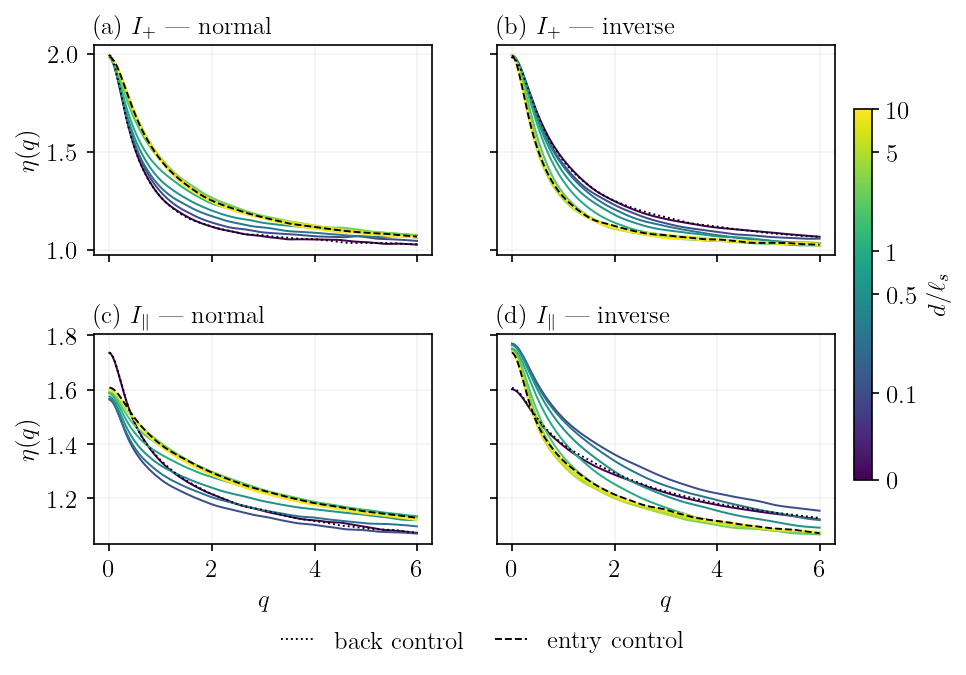

In [13]:

# FIGURA FINAL 1: perfiles circular y lineal en los dos ordenes.
apply(width_frac=1.0)
orders = ["normal", "inverse"]
polarizations = ["circular", "linear"]
m_values = np.asarray(CAMP[("normal", "circular")].m_s_arr, float)
color_norm = matplotlib.colors.SymLogNorm(
    linthresh=0.10, linscale=0.55, vmin=0.0, vmax=float(m_values.max()), base=10
)
profile_cmap = plt.cm.viridis
fig, axes = plt.subplots(
    2, 2, figsize=(TEXTWIDTH_IN, 0.70 * TEXTWIDTH_IN),
    sharex=True, sharey="row", gridspec_kw={"wspace": 0.12, "hspace": 0.12}
)

for row, pol in enumerate(polarizations):
    for col, o in enumerate(orders):
        ax = axes[row, col]
        c = CAMP[(o, pol)]
        for L in c.layers:
            q, E = PROF[(o, pol, L.z)]
            use = q <= CONV["q_view"]
            ax.plot(
                q[use], E[use], color=profile_cmap(color_norm(L.m_s)), lw=0.95
            )

        for which, ls_style in (("back", ":"), ("entry", "--")):
            q, E = CTRL[(o, pol, which)]
            use = q <= CONV["q_view"]
            ax.plot(
                q[use], E[use], color="black", lw=0.9, ls=ls_style,
                label=f"{which} control"
            )
        pol_latex = r"$I_+$" if pol == "circular" else r"$I_\parallel$"
        panel = chr(ord("a") + row * 2 + col)
        ax.set_title(
            f"({panel}) {pol_latex} — {o}", loc="left"
        )
        ax.grid(alpha=0.15)
        if row == 1:
            ax.set_xlabel(r"$q$")
        if col == 0:
            ax.set_ylabel(r"$\eta(q)$")

fig.legend(*axes[1,1].get_legend_handles_labels(), ncol=2, loc="outside lower center",
               frameon=False, columnspacing=1.2, handlelength=1.3)

sm = matplotlib.cm.ScalarMappable(norm=color_norm, cmap=profile_cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.025)
cbar.set_label(r"$d/\ell_s$")
cbar.set_ticks([0.0, 0.1, 0.5, 1.0, 5.0, 10.0])
cbar.set_ticklabels(["0", "0.1", "0.5", "1", "5", "10"])
fig.savefig(FIGDIR / "F1_profiles_polarizations.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "F1_profiles_polarizations.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. Cálculos comunes para forma y ápice

El test de forma siempre se compara dentro del mismo canal. Los dos controles homogéneos
definen el piso físico: las especies no comparten exactamente la misma forma reducida, incluso
después de normalizar amplitud y semianchura.

Para el ápice se emplean los controles homogéneos independientes. La significancia de una
excursión se evalúa con una prueba \(t\) de Welch entre las cinco réplicas del espesor extremo
y las cinco réplicas del control que define la cota correspondiente.


In [14]:

# Controles agrupados por especie y polarizacion.
def species_of(c, which):
    small_is_entry = c.r_entry < c.r_back
    if which == "entry":
        return "small" if small_is_entry else "large"
    return "large" if small_is_entry else "small"


CT = {}
for (o, p), c in CAMP.items():
    for which in ("entry", "back"):
        CT.setdefault((p, species_of(c, which)), []).append(CTRL[(o, p, which)])


# Escalares de las bicapas con IC t al 95 %.
SCAL = {}
for (o, p), c in CAMP.items():
    mu, ci = zip(*[
        scalars_stats(c.sweep, L.keys, c.pol, c.channel, c.l_anchor)
        for L in c.layers
    ])
    MU, CI = np.asarray(mu), np.asarray(ci)
    SCAL[(o, p)] = {
        "m_s": c.m_s_arr,
        "m_star": c.m_star_arr,
        "z": c.z_arr,
        "eta0": MU[:, 0], "ci_eta0": CI[:, 0],
        "rho": MU[:, 1], "ci_rho": CI[:, 1],
        "qh": MU[:, 2], "ci_qh": CI[:, 2],
        "S": MU[:, 3], "ci_S": CI[:, 3],
    }


# Formas normalizadas y piso de los controles, solo en lineal.
POL_FINAL = "linear"
SHAPES = {}
for o in orders:
    c = CAMP[(o, POL_FINAL)]
    SHAPES[o] = [
        normalized_shape(*PROF[(o, POL_FINAL, L.z)]) for L in c.layers
    ]

control_shapes = [
    normalized_shape(*curve)
    for med in ("small", "large")
    for curve in CT[(POL_FINAL, med)]
]
shape_floor = collapse_spread(control_shapes)
shape_spread = {o: collapse_spread(SHAPES[o]) for o in orders}

control_S = np.asarray([
    shape_invariant(*curve)
    for med in ("small", "large")
    for curve in CT[(POL_FINAL, med)]
], float)
S_band = (float(np.nanmin(control_S)), float(np.nanmax(control_S)))

print("Piso físico de forma, canal lineal:", f"{shape_floor:.3e}")
for o in orders:
    print(
        f"{o:7s}: dispersión {shape_spread[o]:.3e} "
        f"= {shape_spread[o]/shape_floor:.2f} x piso"
    )


def rho_replicates(c, keys):
    return np.asarray([
        scalars_one(c.sweep, key, c.pol, c.channel, c.l_anchor)[1]
        for key in keys
    ], float)


# Excursión respecto a controles independientes y prueba de Welch.
RHO_EXC = {}
for o in orders:
    c = CAMP[(o, "linear")]
    layer_reps = [rho_replicates(c, L.keys) for L in c.layers]
    layer_mean = np.asarray([x.mean() for x in layer_reps])

    ctrl_reps = {
        which: rho_replicates(c, c.ctrl[which])
        for which in ("entry", "back")
    }
    ctrl_mean = {which: vals.mean() for which, vals in ctrl_reps.items()}
    low_key = min(ctrl_mean, key=ctrl_mean.get)
    high_key = max(ctrl_mean, key=ctrl_mean.get)

    above = layer_mean - ctrl_mean[high_key]
    below = ctrl_mean[low_key] - layer_mean
    if np.nanmax(above) >= np.nanmax(below):
        idx = int(np.nanargmax(above))
        bound_key = high_key
        delta = float(above[idx])
    else:
        idx = int(np.nanargmax(below))
        bound_key = low_key
        delta = float(-below[idx])

    test = stats.ttest_ind(
        layer_reps[idx], ctrl_reps[bound_key],
        equal_var=False, alternative="two-sided"
    )
    bound = float(ctrl_mean[bound_key])
    RHO_EXC[o] = {
        "idx": idx,
        "m_s": float(c.layers[idx].m_s),
        "rho_ext": float(layer_mean[idx]),
        "low": float(ctrl_mean[low_key]),
        "high": float(ctrl_mean[high_key]),
        "bound": bound,
        "pct": 100.0 * delta / bound,
        "welch_t": float(test.statistic),
        "pvalue": float(test.pvalue),
        "layer_reps": layer_reps,
        "ctrl_reps": ctrl_reps,
    }

display(pd.DataFrame([
    {
        "order": o,
        "d_over_ls": r["m_s"],
        "rho_extreme": r["rho_ext"],
        "control_interval": f"[{r['low']:.4f}, {r['high']:.4f}]",
        "excursion_percent": r["pct"],
        "welch_t": r["welch_t"],
        "p_value": r["pvalue"],
    }
    for o, r in RHO_EXC.items()
]).round(5))


Piso físico de forma, canal lineal: 8.114e-03
normal : dispersión 1.847e-02 = 2.28 x piso
inverse: dispersión 1.639e-02 = 2.02 x piso


,order,d_over_ls,rho_extreme,control_interval,excursion_percent,welch_t,p_value
0,normal,0.25,0.43739,"[0.2631, 0.3933]",11.20347,12.22283,0.00001
1,inverse,0.25,0.23221,"[0.2645, 0.3941]",-12.20049,-9.90800,0.00001


## 6. Figura final 2 — fallo de una forma homogénea común

Si todos los perfiles fueran

$$
\eta(\theta;d)=1+A(d)f\!\left(\theta/\Theta(d)\right),
$$

la normalización

$$
\widetilde f(u)=\frac{\eta(\theta)-1}{\eta(0)-1},
\qquad u=\frac{q}{q_{1/2}},
$$

eliminaría amplitud y escala. La comparación no se hace contra cero, sino contra la
dispersión de los dos controles homogéneos del mismo canal.


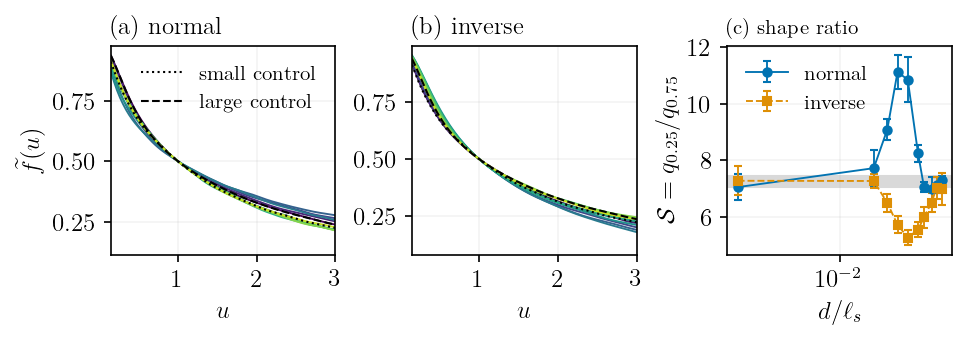

In [26]:

# FIGURA FINAL 2: colapso por orden + invariante de forma.
apply(width_frac=1.0)
fig, axes = plt.subplots(
    1, 3, figsize=(TEXTWIDTH_IN, 0.34 * TEXTWIDTH_IN),
)

for ax, o, panel in zip(axes[:2], orders, ("a", "b")):
    c = CAMP[(o, POL_FINAL)]
    ax.set_title(
        rf"({panel}) {o}",
        loc="left",
    )
    cmap = plt.cm.viridis(np.linspace(0.0, 0.92, len(c.layers)))
    for col, L, sh in zip(cmap, c.layers, SHAPES[o]):
        ax.plot(U_GRID, sh, color=col, lw=0.9)

    for med, ls_style in (("small", ":"), ("large", "--")):
        mean_shape = np.nanmean(
            [normalized_shape(*x) for x in CT[(POL_FINAL, med)]], axis=0
        )
        ax.plot(
            U_GRID, mean_shape, color="black", lw=1.0, ls=ls_style,
            label=f"{med} control"
        )

    ax.set_xlim(0.15, 3.0)
    ax.set_xlabel(r"$u$")
    ax.set_title(
        rf"({panel}) {o}",
        loc="left"
    )
    ax.grid(alpha=0.15)

axes[0].set_ylabel(r"$\widetilde f(u)$")
axes[0].legend(fontsize=10, frameon=False)

axes[2].axhspan(*S_band, color="0.85")
for o in orders:
    D, st = SCAL[(o, POL_FINAL)], STYLE[o]
    axes[2].errorbar(
        D["m_s"], D["S"], yerr=D["ci_S"],
        fmt=st["marker"], ms=4, lw=0.9, ls=st["ls"],
        color=st["color"], capsize=2, label=o
    )
axes[2].set_xscale("log")
axes[2].set_xlabel(r"$d/\ell_s$")
axes[2].set_ylabel(r"$\mathcal{S}=q_{0.25}/q_{0.75}$")
axes[2].set_title("(c) shape ratio", loc="left", fontsize="small")
axes[2].grid(alpha=0.15, which="both")
axes[2].legend(fontsize=10, frameon=False, loc="upper left")

fig.savefig(FIGDIR / "F2_single_scale_failure.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "F2_single_scale_failure.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Figura final 3 — excursión convexa del ápice

En retrodispersión exacta,

$$
\rho\equiv2-\eta(0)=\frac{S}{S+M}.
$$

Si las contribuciones simple y múltiple interpolaran entre los controles con un mismo peso
\(w\), entonces

$$
\rho(w)=
\frac{wS_1+(1-w)S_2}
{w(S_1+M_1)+(1-w)(S_2+M_2)}
$$

sería monótona y permanecería entre \(\rho_1\) y \(\rho_2\). Por tanto,

$$
\rho(d)\notin[\rho_1,\rho_2]\quad\Longrightarrow\quad w_S(d)\neq w_M(d).
$$

Esta es la deducción central. No demuestra la inexistencia de cualquier medio efectivo
imaginable; descarta la interpolación con un peso común para los sectores simple y múltiple.


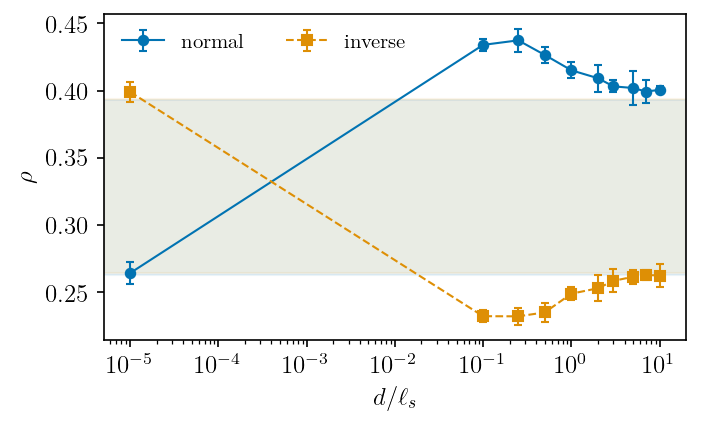

In [16]:

# FIGURA FINAL 3: excursion respecto a controles independientes.
apply(width_frac=0.72)
fig, ax = plt.subplots(figsize=(0.72 * TEXTWIDTH_IN, 0.43 * TEXTWIDTH_IN))



for o in orders:
    D, st, exc = SCAL[(o, "linear")], STYLE[o], RHO_EXC[o]
    ax.axhspan(exc["low"], exc["high"], color=st["color"], alpha=0.08)
    ax.errorbar(
        D["m_s"], D["rho"], yerr=D["ci_rho"],
        fmt=st["marker"], ms=4.5, lw=1.0, ls=st["ls"],
        color=st["color"], capsize=2, label=st["label"]
    )

ax.set_xscale("log")
ax.set_xlabel(r"$d/\ell_s$")
ax.set_ylabel(r"$\rho$")
# ax.grid(alpha=0.15, which="both")
ax.legend(fontsize=10, frameon=False, loc="upper left", ncol=2)
fig.savefig(FIGDIR / "F3_apex_excursion.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "F3_apex_excursion.png", dpi=180, bbox_inches="tight")
plt.show()


## 8. Visualización temporal directa — perfiles CBS

Antes de reducir la evolución a una semianchura, conviene observar los perfiles completos.
Se usa el canal circular protegido porque conserva un ápice cercano al límite recíproco y
permite seguir con mayor estabilidad el estrechamiento temporal del cono.

Las columnas representan una capa de entrada delgada, intermedia y gruesa. Las filas comparan
los dos órdenes. En cada panel se muestran cinco tiempos aproximadamente comunes, expresados
en unidades de \(\tau^*_{\rm entrada}\). Por ello la figura permite separar visualmente tres
efectos: el estrechamiento con el tiempo, la dependencia con el espesor y la inversión del orden.


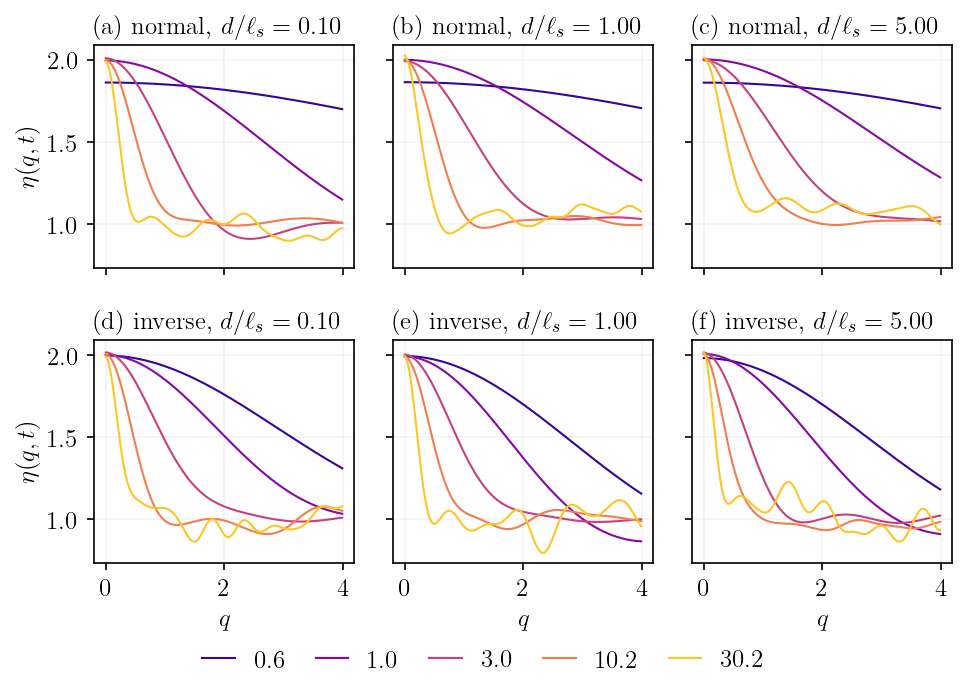

In [25]:

# VISUALIZACION TEMPORAL: seis bicapas y cinco instantes por panel.
POL_TIME = "circular"
orders = ["normal", "inverse"]
TIME_TARGETS = np.array([0.5, 1.0, 3.0, 10.0, 30.0])
THICKNESS_TARGETS = (0.10, 1.00, 5.00)
TIME_COLORS = plt.cm.plasma(np.linspace(0.08, 0.88, len(TIME_TARGETS)))


def nearest_layer(c, target):
    return min(c.layers, key=lambda L: abs(L.m_s - target))


def nearest_time_index(c, target):
    idx = int(np.rint(target * c.tau_entry / c.dt_sim + 0.5))
    idx = int(np.clip(idx, 1, c.n_time))
    actual = (idx - 0.5) * c.dt_sim / c.tau_entry
    return idx, actual


apply(width_frac=1.0)
fig, axes = plt.subplots(
    2, 3, figsize=(TEXTWIDTH_IN, 0.72 * TEXTWIDTH_IN),
    sharex=True, sharey=True,
    gridspec_kw={"wspace": 0.10, "hspace": 0.10}
)
# fig.subplots_adjust(
#     left=0.08, right=0.99, bottom=0.10, top=0.80,
#     wspace=0.15, hspace=0.45
# )

for row, o in enumerate(orders):
    c = CAMP[(o, POL_TIME)]
    time_pairs = [nearest_time_index(c, t) for t in TIME_TARGETS]
    for col, target_m in enumerate(THICKNESS_TARGETS):
        ax = axes[row, col]
        L = nearest_layer(c, target_m)
        for color, (it, t_actual) in zip(TIME_COLORS, time_pairs):
            q, E = profile_sum(
                c.sweep, L.keys, c.pol, c.channel, c.l_anchor,
                time_index=it
            )
            use = q <= 4.0
            ax.plot(
                q[use], E[use], color=color, lw=1.0,
                label=rf"${t_actual:.1f}$"
            )

        panel = chr(ord("a") + row * 3 + col)
        ax.set_title(
            rf"({panel}) {o}, $d/\ell_s={L.m_s:.2f}$",
            loc="left",
        )
        ax.grid(alpha=0.15)
        if row == 1:
            ax.set_xlabel(r"$q$")
        if col == 0:
            ax.set_ylabel(r"$\eta(q,t)$")

handles, labels = axes[0, 2].get_legend_handles_labels()
fig.legend(*axes[1,1].get_legend_handles_labels(), ncol=5, loc="outside lower center",
               frameon=False, columnspacing=1.2, handlelength=1.3)
fig.savefig(FIGDIR / "T1_time_resolved_cbs_profiles.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "T1_time_resolved_cbs_profiles.png", dpi=180, bbox_inches="tight")
plt.show()


## 9. Figura final 4 — recuperación temporal medida sobre las bicapas

La versión exploratoria calculaba \(R_\infty\) dividiendo los dos controles homogéneos.
Eso valida el escalamiento temporal, pero no constituye una extracción desde la bicapa.

Aquí el cociente se calcula realmente entre cada **bicapa delgada** y su control de entrada:

$$
R_d(t)=\frac{q_{1/2}^{\,d}(t)}{q_{1/2}^{\,\mathrm{ent}}(t)}.
$$

Se seleccionan antes de mirar el resultado los tres espesores no nulos con
\(0.1\le d/\ell_s\le0.5\). Si sus caminos tardíos son dominados por el sustrato,

$$
R_d(t\to\infty)\longrightarrow
\sqrt{\frac{\ell^*_{\rm ent}}{\ell^*_{\rm fon}}}.
$$

La figura se conserva si las tres curvas muestran una meseta compatible y la recuperación
de \(\ell^*_{\rm fon}\) es estable entre espesores. La sección siguiente aplica esta condición
antes de recomendarla para el cuerpo principal.


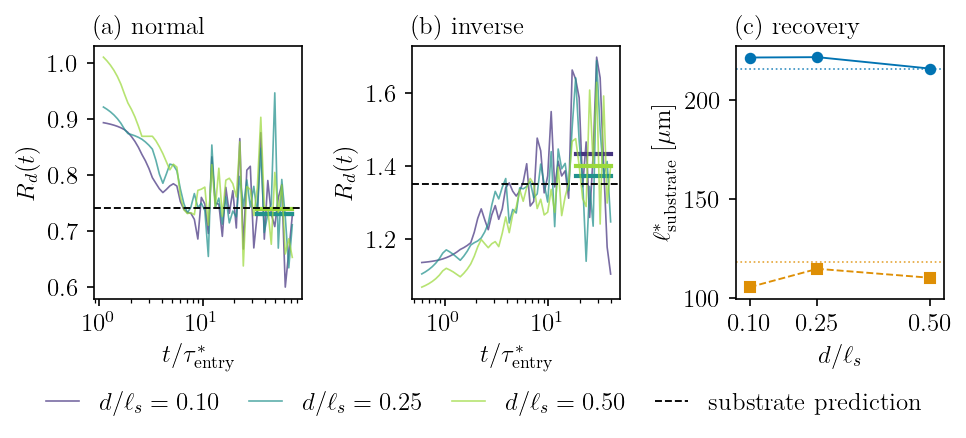

,order,d_over_ls,R_late,R_pred,l_back_hat,l_back_true,relative_error
0,normal,0.10,0.7304,0.7404,221.2585,215.3057,0.0276
1,normal,0.25,0.7301,0.7404,221.4405,215.3057,0.0285
2,normal,0.50,0.7398,0.7404,215.6556,215.3057,0.0016
3,inverse,0.10,1.4307,1.3504,105.2586,118.1349,-0.1090
4,inverse,0.25,1.3716,1.3504,114.5120,118.1349,-0.0307
5,inverse,0.50,1.3997,1.3504,109.9720,118.1349,-0.0691


In [18]:

# FIGURA FINAL 4 (condicionada): meseta tardia medida en bicapas delgadas.
TIME_STRIDE = 1
POL_TIME = "circular"


def noise_tail(q, E, q_min=CONV["q_view"]):
    use = q > q_min
    return float(np.std(E[use])) if np.count_nonzero(use) > 5 else np.inf


def gated_width(c, keys):
    ts, widths = [], []
    for it in range(1, c.n_time + 1, TIME_STRIDE):
        try:
            q, E = profile_sum(
                c.sweep, keys, c.pol, c.channel, c.l_anchor,
                time_index=int(it)
            )
        except Exception:
            continue
        e0 = apex_value(q, E)
        if not np.isfinite(e0):
            continue
        if (e0 - 1.0) < CONV["snr_min_time"] * noise_tail(q, E):
            continue
        qh = level_q(q, E, 0.5)
        if np.isfinite(qh) and qh > 0:
            ts.append((it - 0.5) * c.dt_sim / c.tau_entry)
            widths.append(qh)
    return np.asarray(ts), np.asarray(widths)


TEMP = {}
for o in orders:
    c = CAMP[(o, POL_TIME)]
    TEMP[(o, "entry")] = gated_width(c, c.ctrl["entry"])
    for L in c.layers:
        if 0.099 <= L.m_s <= 0.501:
            TEMP[(o, L.z)] = gated_width(c, L.keys)


def ratio_curve(c, L):
    te, qe = TEMP[(c.order, "entry")]
    td, qd = TEMP[(c.order, L.z)]
    lo, hi = max(te.min(), td.min()), min(te.max(), td.max())
    grid = np.geomspace(lo, hi, 55)
    ratio = np.interp(grid, td, qd) / np.interp(grid, te, qe)
    return grid, ratio


TEMP_ROWS = []
apply(width_frac=1.0)
fig, axes = plt.subplots(
    1, 3, figsize=(TEXTWIDTH_IN, 0.45 * TEXTWIDTH_IN),
    gridspec_kw={"wspace": 0.10}
)

for ax, o, panel in zip(axes[:2], orders, ("a", "b")):
    c = CAMP[(o, POL_TIME)]
    pred = np.sqrt(c.l_entry / c.l_back)
    selected = [L for L in c.layers if 0.099 <= L.m_s <= 0.501]
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(selected)))
    for col, L in zip(colors, selected):
        t, ratio = ratio_curve(c, L)
        nlate = max(5, len(ratio) // 5)
        plateau = float(np.nanmedian(ratio[-nlate:]))
        l_hat = float(c.l_entry / plateau**2)
        TEMP_ROWS.append({
            "order": o, "d_over_ls": L.m_s,
            "R_late": plateau, "R_pred": pred,
            "l_back_hat": l_hat, "l_back_true": c.l_back,
            "relative_error": l_hat / c.l_back - 1.0,
        })
        ax.plot(t, ratio, color=col, lw=0.8, alpha=0.72,
                label=rf"$d/\ell_s={L.m_s:.2f}$")
        ax.plot(t[-nlate:], np.full(nlate, plateau), color=col, lw=2.0)

    ax.axhline(pred, color="black", lw=0.9, ls="--", label="substrate prediction")
    ax.set_xscale("log")
    ax.set_xlabel(r"$t/\tau^*_{\rm entry}$")
    ax.set_ylabel(r"$R_d(t)$")
    ax.set_title(f"({panel}) {o}", loc="left")

TEMP_REC = pd.DataFrame(TEMP_ROWS)
for o in orders:
    sub = TEMP_REC[TEMP_REC["order"] == o]
    st = STYLE[o]
    axes[2].plot(
        sub["d_over_ls"], sub["l_back_hat"],
        st["ls"], marker=st["marker"], ms=4.5,
        color=st["color"], lw=0.9, label=st["label"]
    )
    axes[2].axhline(
        sub["l_back_true"].iloc[0], color=st["color"],
        lw=0.8, ls=":", alpha=0.8
    )

axes[2].set_xscale("linear")
axes[2].set_xticks([0.10, 0.25, 0.50])
axes[2].set_xlim(0.07, 0.53)
axes[2].set_xlabel(r"$d/\ell_s$")
axes[2].set_ylabel(r"$\ell^*_{\rm substrate}$ [$\mu$m]")
axes[2].set_title("(c) recovery", loc="left")

fig.legend(*axes[1].get_legend_handles_labels(), ncol=5, loc="outside lower center",
               frameon=False, columnspacing=1.2, handlelength=1.3)

fig.savefig(FIGDIR / "F4_bilayer_temporal_recovery.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "F4_bilayer_temporal_recovery.png", dpi=180, bbox_inches="tight")
plt.show()
display(TEMP_REC.round(4))


## 10. Compuerta de estabilidad para la figura temporal

La celda siguiente aplica un criterio explícito: la figura temporal se recomienda para el
cuerpo principal sólo si el error absoluto mediano en \(\ell^*_{\rm fon}\) es menor que 10 %
en **cada** orden y ningún espesor seleccionado supera 20 %. De lo contrario se conserva como
diagnóstico o perspectiva.


In [19]:

TEMP_DECISION = []
for o in orders:
    sub = TEMP_REC[TEMP_REC["order"] == o]
    med = float(sub["relative_error"].abs().median())
    worst = float(sub["relative_error"].abs().max())
    keep = med < 0.10 and worst < 0.20
    TEMP_DECISION.append({
        "order": o,
        "median_abs_error": med,
        "max_abs_error": worst,
        "passes_final_figure_gate": keep,
    })

TEMP_GATE = pd.DataFrame(TEMP_DECISION)
display(TEMP_GATE)
if TEMP_GATE["passes_final_figure_gate"].all():
    print("DECISIÓN: F4 supera la compuerta y puede proponerse como figura principal.")
else:
    print("DECISIÓN: F4 queda como diagnóstico/perspectiva; no usar como figura principal.")


,order,median_abs_error,max_abs_error,passes_final_figure_gate
0,normal,0.027648,0.028493,True
1,inverse,0.069098,0.108996,True


DECISIÓN: F4 supera la compuerta y puede proponerse como figura principal.


## 11. Resumen para redacción

### Resultados principales

1. Los perfiles lineales cambian de forma con el espesor y con el orden.
2. La dispersión de auto-similitud supera el piso físico de los controles en el canal lineal.
3. El ápice sale del intervalo de los controles homogéneos en sentidos opuestos; por la cota
   convexa, las contribuciones simple y múltiple no interpolan con el mismo peso.

### Números reproducidos en esta ejecución

| Resultado | Orden normal | Orden inverso |
|---|---:|---:|
| Dispersión de forma / piso homogéneo | 2.28 | 2.02 |
| Excursión del ápice | +11.2 % | -12.2 % |
| Prueba de Welch contra el control extremo | \(t_W=12.2,\ p=7\times10^{-6}\) | \(t_W=-9.9,\ p=9\times10^{-6}\) |
| Error absoluto mediano al recuperar \(\ell^*_{\rm fon}\) | 2.8 % | 6.9 % |
| Error absoluto máximo al recuperar \(\ell^*_{\rm fon}\) | 2.9 % | 10.9 % |

Los valores temporales se obtienen de tres bicapas no nulas
(\(d/\ell_s=0.10,\ 0.25,\ 0.50\)), no del cociente entre controles.

### Formulación segura

> La bicapa no puede describirse mediante el simple reescalado angular de una forma homogénea
> común. La excursión del ápice demuestra además que los sectores simple y múltiple responden
> con pesos de profundidad diferentes.

### Resultados retirados del flujo final

- No se decide una regla universal de sondeo basada en \(\ell_s\) o \(\ell^*\).
- El prefactor \(3/2\) del tiempo de quiebre no es compatible con la grilla temporal.
- La ley browniana de saturación de \(w(d)\) está refutada.
- La inversión del espesor mediante \(w(d)\) tiene errores máximos demasiado grandes para ser
  un resultado principal.
- La diferencia directa entre órdenes es redundante con la excursión opuesta del ápice.


In [20]:

# Inventario final de artefactos y numeros esenciales.
SUMMARY = pd.DataFrame([
    {
        "result": "single-scale failure",
        "normal": shape_spread["normal"] / shape_floor,
        "inverse": shape_spread["inverse"] / shape_floor,
        "units": "x homogeneous-shape floor",
    },
    {
        "result": "apex excursion",
        "normal": RHO_EXC["normal"]["pct"],
        "inverse": RHO_EXC["inverse"]["pct"],
        "units": "%",
    },
    {
        "result": "Welch p-value",
        "normal": RHO_EXC["normal"]["pvalue"],
        "inverse": RHO_EXC["inverse"]["pvalue"],
        "units": "",
    },
])
display(SUMMARY)

print("\nFiguras generadas:")
for path in sorted(FIGDIR.glob("*.pdf")):
    print(f"  {path.name:48s} {path.stat().st_size/1024:8.1f} kB")


,result,normal,inverse,units
0,single-scale failure,2.275920,2.020158,x homogeneous-shape floor
1,apex excursion,11.203474,-12.200493,%
2,Welch p-value,0.000007,0.000009,



Figuras generadas:
  F1_profiles_polarizations.pdf                       340.5 kB
  F2_single_scale_failure.pdf                         738.9 kB
  F3_apex_excursion.pdf                               442.0 kB
  F4_bilayer_temporal_recovery.pdf                    327.4 kB
  T1_time_resolved_cbs_profiles.pdf                   187.6 kB


## 12. Intensidades absolutas en el ápice: prueba de la separación simple/múltiple

El análisis anterior utiliza principalmente el cociente $\eta=C/B$. Aquí se conservan
por separado la intensidad coherente $C$ y el fondo incoherente $B$ en $q=0$. Definimos

$$
U\equiv 2B-C,\qquad P\equiv C-B.
$$

Si todo camino múltiple del canal lineal co-polarizado duplicara exactamente su intensidad
en retrodispersión, entonces $U=S$ sería la dispersión simple y $P=M$ la múltiple. Bajo esa
hipótesis, para $\mu_s$ común, sin absorción ni contraste de índice,

$$
W_U(d)=\frac{U(d)-U_{\rm substrate}}{U_{\rm entry}-U_{\rm substrate}}
=1-e^{-2d/\ell_s},\qquad
\widehat{d/\ell_s}=-\tfrac12\ln(1-W_U).
$$

La igualdad $U=S$ no se presupone: se somete a una compuerta cuantitativa. Si $W_U$ sale
de $[0,1)$ o no sigue la ley anterior, $U$ se interpreta únicamente como el sector no
duplicado (déficit de interferencia), y la inversión de espesor se rechaza.


In [21]:
# ===========================================================================
# 12a -- C y B absolutos en q=0; combinaciones U=2B-C y P=C-B
# ===========================================================================
POL_COMPONENTS = "linear"
N_BOOT_COMPONENTS = 20000
BOOT_SEED = 20260811


def apex_cb_one(c, key, time_index=0):
    """C, B, U y P de una réplica en el bin físico q=0 de la ventana fina.

    C y B comparten la misma historia Monte Carlo; formar U y P antes de
    cualquier remuestreo conserva esa covarianza.
    """
    p1, _ = raw_profiles(c.sweep, key, c.pol, c.channel, time_index)
    q = k * c.l_anchor * np.asarray(p1.theta, float)
    i0 = int(np.argmin(np.abs(q)))
    if abs(q[i0]) > 1e-10:
        raise RuntimeError(f"[{c.tag}] la ventana fina no contiene q=0")
    C = float(_chan_get(p1, c.channel, "coherent")[i0])
    B = float(_chan_get(p1, c.channel, "incoherent")[i0])
    return np.array([C, B, 2.0 * B - C, C - B, C / B], float)


COMP_NAMES = ["C", "B", "U", "P", "eta_raw"]


def component_samples(c, keys):
    return pd.DataFrame(
        np.vstack([apex_cb_one(c, key) for key in keys]),
        columns=COMP_NAMES,
    )


def mean_ci95(values):
    x = np.asarray(values, float)
    return float(x.mean()), float(t_ci(len(x)) * x.std(ddof=1) / np.sqrt(len(x)))


def bootstrap_depth_weights(layer, entry, back, seed):
    """Bootstrap estratificado: remuestrea independientemente las tres configuraciones."""
    rng = np.random.default_rng(seed)
    L, E, D = (np.asarray(x, float) for x in (layer, entry, back))
    n = N_BOOT_COMPONENTS
    lm = L[rng.integers(0, len(L), (n, len(L)))].mean(1)
    em = E[rng.integers(0, len(E), (n, len(E)))].mean(1)
    dm = D[rng.integers(0, len(D), (n, len(D)))].mean(1)
    denom = em - dm
    good_den = np.abs(denom) > 1e-15
    w = np.full(n, np.nan)
    w[good_den] = (lm[good_den] - dm[good_den]) / denom[good_den]
    physical = np.isfinite(w) & (w >= 0.0) & (w < 1.0)
    tau = np.full(n, np.nan)
    tau[physical] = -0.5 * np.log1p(-w[physical])
    return w, tau, float(np.mean(physical))


COMP_SAMPLES = {}
COMP_ROWS = []
DEPTH_ROWS = []

for io, o in enumerate(orders):
    c = CAMP[(o, POL_COMPONENTS)]
    entry = component_samples(c, c.ctrl["entry"])
    back = component_samples(c, c.ctrl["back"])
    COMP_SAMPLES[(o, "entry")] = entry
    COMP_SAMPLES[(o, "back")] = back

    for role, data, tau_true in (("entry", entry, np.inf),
                                  ("back", back, 0.0)):
        row = {"order": o, "kind": role, "d_over_ls": tau_true}
        for name in COMP_NAMES:
            row[name], row[f"ci_{name}"] = mean_ci95(data[name])
        COMP_ROWS.append(row)

    for iL, L in enumerate(c.layers):
        data = component_samples(c, L.keys)
        COMP_SAMPLES[(o, L.z)] = data
        row = {"order": o, "kind": "bilayer", "d_over_ls": L.m_s,
               "z_um": L.z}
        for name in COMP_NAMES:
            row[name], row[f"ci_{name}"] = mean_ci95(data[name])
        COMP_ROWS.append(row)

        inv = {"order": o, "d_over_ls_true": L.m_s, "z_true_um": L.z}
        for j, name in enumerate(("U", "B", "P")):
            lv = data[name].to_numpy()
            ev = entry[name].to_numpy()
            bv = back[name].to_numpy()
            central = (lv.mean() - bv.mean()) / (ev.mean() - bv.mean())
            wb, tb, valid_fraction = bootstrap_depth_weights(
                lv, ev, bv, BOOT_SEED + 1000 * io + 100 * iL + j
            )
            inv[f"W_{name}"] = float(central)
            inv[f"W_{name}_lo"], inv[f"W_{name}_hi"] = np.nanquantile(wb, [0.025, 0.975])
            inv[f"physical_fraction_{name}"] = valid_fraction
            if name == "U" and 0.0 <= central < 1.0:
                inv["d_over_ls_hat"] = float(-0.5 * np.log1p(-central))
                finite_tau = tb[np.isfinite(tb)]
                if len(finite_tau):
                    inv["d_over_ls_lo"], inv["d_over_ls_hi"] = np.quantile(
                        finite_tau, [0.025, 0.975]
                    )
            elif name == "U":
                inv["d_over_ls_hat"] = np.nan
                inv["d_over_ls_lo"] = np.nan
                inv["d_over_ls_hi"] = np.nan
        inv["W_single_theory"] = float(1.0 - np.exp(-2.0 * L.m_s))
        DEPTH_ROWS.append(inv)

APEX_COMPONENTS = pd.DataFrame(COMP_ROWS)
DEPTH_INVERSION = pd.DataFrame(DEPTH_ROWS)


In [22]:
# Tablas auditables: valores absolutos, pesos normalizados e inversión tentativa.
display(APEX_COMPONENTS[APEX_COMPONENTS["kind"] == "bilayer"][
    ["order", "d_over_ls", "C", "B", "U", "P", "eta_raw"]
].round(7))
display(DEPTH_INVERSION[[
    "order", "d_over_ls_true", "W_U", "W_single_theory",
    "physical_fraction_U", "d_over_ls_hat", "d_over_ls_lo",
    "d_over_ls_hi", "W_B", "W_P"
]].round(4))


,order,d_over_ls,C,B,U,P,eta_raw
2,normal,0.00001,0.004534,0.002580,0.000627,0.001954,1.757073
3,normal,0.10000,0.004205,0.002620,0.001035,0.001585,1.604858
4,normal,0.25000,0.004290,0.002666,0.001041,0.001625,1.609503
5,normal,0.50000,0.004393,0.002711,0.001029,0.001682,1.620374
6,normal,1.00000,0.004490,0.002759,0.001027,0.001731,1.627586
7,normal,2.00000,0.004617,0.002821,0.001024,0.001796,1.636840
8,normal,3.00000,0.004648,0.002838,0.001027,0.001810,1.637898
9,normal,5.00000,0.004688,0.002857,0.001026,0.001831,1.640982
10,normal,7.00000,0.004780,0.002904,0.001028,0.001876,1.646078
11,normal,10.00000,0.004803,0.002919,0.001035,0.001884,1.645539


,order,d_over_ls_true,W_U,W_single_theory,physical_fraction_U,d_over_ls_hat,d_over_ls_lo,d_over_ls_hi,W_B,W_P
0,normal,0.00,0.0135,0.0000,0.9053,0.0068,0.0012,0.0186,-0.0161,0.1524
1,normal,0.10,1.0113,0.1813,0.2066,NaN,NaN,NaN,0.1019,5.2743
2,normal,0.25,1.0248,0.3935,0.0445,NaN,NaN,NaN,0.2362,4.7216
3,normal,0.50,0.9963,0.6321,0.6092,2.8053,1.7132,3.8170,0.3714,3.9259
4,normal,1.00,0.9918,0.8647,0.7638,2.4040,1.7501,3.6194,0.5123,3.2396
5,normal,2.00,0.9842,0.9817,0.8089,2.0723,1.4672,3.3259,0.6953,2.3382
6,normal,3.00,0.9917,0.9975,0.6987,2.3930,1.6156,3.5823,0.7456,2.1452
7,normal,5.00,0.9873,1.0000,0.7800,2.1836,1.5481,3.4193,0.8023,1.8544
8,normal,7.00,0.9927,1.0000,0.6391,2.4602,1.5070,3.5227,0.9425,1.2283
9,normal,10.00,1.0093,1.0000,0.2458,NaN,NaN,NaN,0.9864,1.1166


## 13. Figura diagnóstica — componentes del ápice y ensayo de espesor

Los dos primeros paneles muestran las combinaciones absolutas $U$ y $P$. El tercero
compara el peso obtenido de $U$ con la ley de dispersión simple. El cuarto muestra la
inversión solamente donde el valor central pertenece al dominio físico $0\le W_U<1$.
La ausencia de un punto no es un dato perdido: significa que la inversión no está definida.


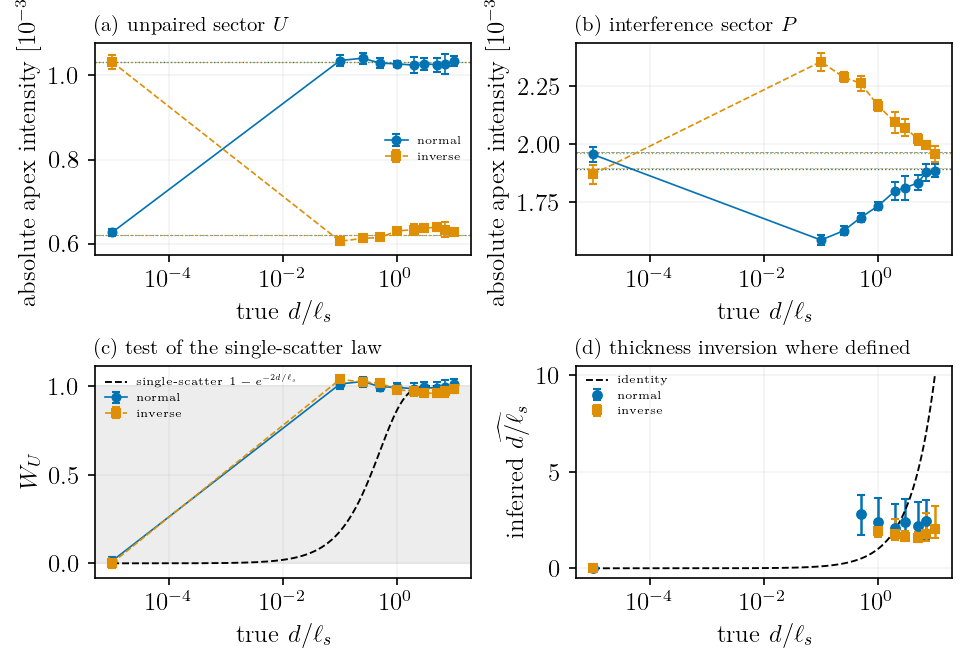

In [23]:
# FIGURA F5: no fuerza una interpretación S/M; muestra si los datos la permiten.
apply(width_frac=1.0)
fig, axes = plt.subplots(2, 2, figsize=(TEXTWIDTH_IN, 0.68 * TEXTWIDTH_IN),
                         constrained_layout=True)

for o in orders:
    st = STYLE[o]
    sub = APEX_COMPONENTS[(APEX_COMPONENTS["order"] == o) &
                          (APEX_COMPONENTS["kind"] == "bilayer")].sort_values("d_over_ls")
    for ax, name, panel_title in ((axes[0, 0], "U", r"$U=2B-C$"),
                                  (axes[0, 1], "P", r"$P=C-B$")):
        ax.errorbar(sub["d_over_ls"], 1e3 * sub[name],
                    yerr=1e3 * sub[f"ci_{name}"],
                    color=st["color"], marker=st["marker"], ls=st["ls"],
                    ms=3.8, lw=0.8, capsize=1.8, label=st["label"])
        ent = APEX_COMPONENTS[(APEX_COMPONENTS["order"] == o) &
                              (APEX_COMPONENTS["kind"] == "entry")][name].iloc[0]
        back = APEX_COMPONENTS[(APEX_COMPONENTS["order"] == o) &
                               (APEX_COMPONENTS["kind"] == "back")][name].iloc[0]
        ax.axhline(1e3 * ent, color=st["color"], lw=0.65, ls=":")
        ax.axhline(1e3 * back, color=st["color"], lw=0.45, ls="--", alpha=0.65)

    inv = DEPTH_INVERSION[DEPTH_INVERSION["order"] == o].sort_values("d_over_ls_true")
    axes[1, 0].errorbar(
        inv["d_over_ls_true"], inv["W_U"],
        yerr=np.vstack([inv["W_U"] - inv["W_U_lo"],
                        inv["W_U_hi"] - inv["W_U"]]),
        color=st["color"], marker=st["marker"], ls=st["ls"],
        ms=3.8, lw=0.8, capsize=1.8, label=st["label"]
    )
    valid = np.isfinite(inv["d_over_ls_hat"])
    axes[1, 1].errorbar(
        inv.loc[valid, "d_over_ls_true"], inv.loc[valid, "d_over_ls_hat"],
        yerr=np.vstack([inv.loc[valid, "d_over_ls_hat"] - inv.loc[valid, "d_over_ls_lo"],
                        inv.loc[valid, "d_over_ls_hi"] - inv.loc[valid, "d_over_ls_hat"]]),
        color=st["color"], marker=st["marker"], ls="none",
        ms=4.2, capsize=1.8, label=st["label"]
    )

tau_grid = np.geomspace(1e-5, 10.0, 300)
axes[1, 0].plot(tau_grid, 1.0 - np.exp(-2.0 * tau_grid), "k--", lw=0.9,
                label=r"single-scatter $1-e^{-2d/\ell_s}$")
axes[1, 0].axhspan(0.0, 1.0, color="0.93", zorder=-5)
axes[1, 1].plot(tau_grid, tau_grid, "k--", lw=0.9, label="identity")

for ax in axes.ravel():
    ax.set_xscale("log")
    ax.set_xlabel(r"true $d/\ell_s$")
    ax.grid(alpha=0.15, which="both")
axes[0, 0].set_ylabel(r"absolute apex intensity [$10^{-3}$]")
axes[0, 1].set_ylabel(r"absolute apex intensity [$10^{-3}$]")
axes[1, 0].set_ylabel(r"$W_U$")
axes[1, 1].set_ylabel(r"inferred $\widehat{d/\ell_s}$")
axes[0, 0].set_title(r"(a) unpaired sector $U$", loc="left", fontsize="small")
axes[0, 1].set_title(r"(b) interference sector $P$", loc="left", fontsize="small")
axes[1, 0].set_title("(c) test of the single-scatter law", loc="left", fontsize="small")
axes[1, 1].set_title("(d) thickness inversion where defined", loc="left", fontsize="small")
axes[0, 0].legend(fontsize=5.6, frameon=False)
axes[1, 0].legend(fontsize=5.3, frameon=False)
axes[1, 1].legend(fontsize=5.3, frameon=False)

fig.savefig(FIGDIR / "F5_apex_components_thickness_test.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "F5_apex_components_thickness_test.png", dpi=180, bbox_inches="tight")
plt.show()


![Absolute apex components and thickness test](figs_tesis_bicapa_mus_final/F5_apex_components_thickness_test.png)


## 14. Compuerta de identificabilidad y conclusión del nuevo análisis

Esta compuerta evita interpretar una identidad algebraica como separación física de órdenes.
Se exige simultáneamente que el peso permanezca en su dominio, siga la ley de dispersión
simple y recupere el espesor sin errores grandes. La prueba se realiza sobre las bicapas
con $0<d/\ell_s\le2$, antes de la saturación inevitable de cualquier sonda superficial.


In [24]:
# Compuerta conservadora para decidir si U puede llamarse S y usarse como espesímetro.
DIRECT_GATE_ROWS = []
for o in orders:
    sub = DEPTH_INVERSION[(DEPTH_INVERSION["order"] == o) &
                          (DEPTH_INVERSION["d_over_ls_true"] > 1e-4) &
                          (DEPTH_INVERSION["d_over_ls_true"] <= 2.0)].copy()
    rmse_w = float(np.sqrt(np.mean((sub["W_U"] - sub["W_single_theory"]) ** 2)))
    physical_points = float(np.mean((sub["W_U"] >= 0.0) & (sub["W_U"] < 1.0)))
    finite = sub[np.isfinite(sub["d_over_ls_hat"])].copy()
    med_abs = float(np.median(np.abs(finite["d_over_ls_hat"] -
                                     finite["d_over_ls_true"]))) if len(finite) else np.inf
    keep = rmse_w < 0.10 and physical_points >= 0.80 and med_abs < 0.20
    DIRECT_GATE_ROWS.append({
        "order": o,
        "RMSE_W_vs_single_scatter": rmse_w,
        "fraction_central_points_in_domain": physical_points,
        "median_abs_error_d_over_ls": med_abs,
        "passes_direct_thickness_gate": keep,
    })

DIRECT_GATE = pd.DataFrame(DIRECT_GATE_ROWS)
display(DIRECT_GATE.round(4))

if DIRECT_GATE["passes_direct_thickness_gate"].all():
    print("DECISIÓN: U es compatible con dispersión simple y permite proponer d/l_s.")
else:
    print("DECISIÓN: RECHAZAR la inversión directa de espesor desde U=2B-C.")
    print("U debe llamarse sector no duplicado, no dispersión simple medida.")
    print("Para medir d/l_s se necesita acumular explícitamente el orden N=1, "
          "o ajustar conjuntamente B(q,t) con un modelo directo de bicapa.")


def thickness_from_order1(S1, S1_entry, S1_substrate):
    """Inversión válida sólo para una intensidad N=1 realmente separada."""
    W = (np.asarray(S1) - S1_substrate) / (S1_entry - S1_substrate)
    out = np.full_like(np.asarray(W, float), np.nan)
    valid = (W >= 0.0) & (W < 1.0)
    out[valid] = -0.5 * np.log1p(-W[valid])
    return out


,order,RMSE_W_vs_single_scatter,fraction_central_points_in_domain,median_abs_error_d_over_ls,passes_direct_thickness_gate
0,normal,0.5559,0.50,1.8546,False
1,inverse,0.5674,0.25,0.9151,False


DECISIÓN: RECHAZAR la inversión directa de espesor desde U=2B-C.
U debe llamarse sector no duplicado, no dispersión simple medida.
Para medir d/l_s se necesita acumular explícitamente el orden N=1, o ajustar conjuntamente B(q,t) con un modelo directo de bicapa.


### Lectura física segura

- $C$ y $B$ absolutos sí contienen información que $\eta$ elimina.
- En estos datos vectoriales, $U=2B-C$ no aísla por sí solo el orden uno: incluye cualquier
  déficit de duplicación de los caminos múltiples en el canal proyectado.
- Por ello, la excursión del ápice sigue demostrando pesos de profundidad distintos, pero no
  puede convertirse directamente en espesor con la campaña agregada actual.
- La siguiente campaña mínima debe acumular el detector CBS por orden de dispersión, al menos
  $N=1$, $N=2$ y $N\ge3$. Entonces $N=1$ permite probar la ley exponencial y $N\ge2$ conserva
  la información de transporte temporal del sustrato.
- Una alternativa observable experimentalmente es ajustar conjuntamente el fondo absoluto
  $B(q,t)$ y el exceso coherente $C-B$ mediante el modelo directo, reportando la correlación
  entre $d$, $\mu_s$ y $g$ en vez de asumir que un único escalar los separa.
